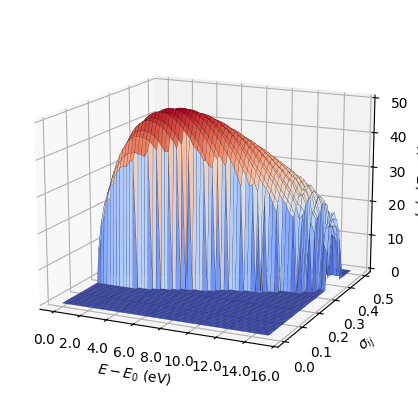

In [3]:
'''
	2D configurational DOS of NCM layered oxide from MUCA simulation

	Created on Oct 02, 2023 at RISM (Shinshu University)
	Last update: Jul 30, 2026 16:45 JST

    Copyright © 2022-2026 Quang Nguyen. All rights reserved.
'''

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

compound = 'NCM523'
pair     = 'AA'
datafile = '../MCMC_Stage2/'+compound+'_'+pair+'_Hist2D.dat'
data     = np.loadtxt(datafile, usecols=[1,3,5])
NE, NBF  = 60, 60
En       = data[:,0] - np.min(data[:,0])
BFn      = data[:,1]
Hist     = data[:,2]
En       = En.reshape((NE, NBF))
BFn      = BFn.reshape((NE, NBF))
Hist     = Hist.reshape((NE, NBF))
ln_gE    = np.loadtxt('../MCMC_Stage1/'+compound+'_HnDOSvsE.dat', usecols=[5])
ln_gE    = ln_gE - np.min(ln_gE)
ln_gEBF  = np.zeros(np.shape(Hist))
for iE in range(NE):
    for iBF in range(NBF):
        if Hist[iE, iBF] == 0.0:
            ln_gEBF[iE, iBF] = 0
        else:
            ln_gEBF[iE, iBF] = ln_gE[iE] + np.log(Hist[iE, iBF])

fig      = plt.figure(figsize=(5,4), constrained_layout=True)
ax       = fig.add_subplot(111, projection='3d')
cmap     = mpl.colormaps['coolwarm']
ax.view_init(elev=15, azim=-65)
ax.set_proj_type('persp', focal_length=0.75)
ax.plot_surface(En, BFn, ln_gEBF, rcount=NE, ccount=NBF, cmap=cmap, edgecolor='black', linewidth=0.1, antialiased=True)
ax.set_xlabel(r'$E-E_{0}$ (eV)', fontsize=10)
ax.set_ylabel(r'$\sigma_{ij}$', fontsize=10)
ax.set_zlabel(r'$ln(g(E,\sigma_{ij}))$', fontsize=10)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.show()